# MILP MODELS

##### IMPORT PACKAGES

In [1]:
import pyomo.environ as pyo
import numpy as np
from datetime import datetime, timedelta

from dataclasses import dataclass
import matplotlib.pyplot as plt

#### PARAMETERS

In [2]:
granularity = 15
horizon = 96
dt = granularity / 60
now = datetime(2026,9,8,10,0)

Define how we simulate the price of electricity for a dataset to work with on the models. It depends on the time of the day + randomness

In [3]:
def price_at_time(hour, rng, previous_price=None):
    """

    Price unit: €/kWh
    """

    # -------------------------
    # Base price
    # -------------------------
    base_price = 0.075

    # -------------------------
    # Morning demand peak
    # -------------------------
    morning_peak = (
        0.045
        * np.exp(
            -0.5 * ((hour - 8) / 2.0) ** 2
        )
    )

    # -------------------------
    # Evening demand peak
    # -------------------------
    evening_peak = (
        0.060
        * np.exp(
            -0.5 * ((hour - 18) / 2.5) ** 2
        )
    )

    # -------------------------
    # Midday renewable effect
    # -------------------------
    midday_effect = (
        -0.040
        * np.exp(
            -0.5 * ((hour - 13) / 2.5) ** 2
        )
    )

    # -------------------------
    # Low nighttime demand
    # -------------------------
    night_effect = (
        -0.025
        * np.exp(
            -0.5 * ((hour - 3) / 2.5) ** 2
        )
    )

    theoretical_price = (
        base_price
        + morning_peak
        + evening_peak
        + midday_effect
        + night_effect
    )

    # -------------------------
    # Random market fluctuation
    # -------------------------
    random_component = rng.normal(0, 0.01)

    price = theoretical_price + random_component

    # -------------------------
    # Temporal correlation
    # -------------------------
    if previous_price is not None:
        price = (
            0.75 * previous_price
            + 0.25 * price
        )

    return price

Initialize a Day-ahead price data list to work with on the models

In [4]:
def initialize_prices(start_hour=10, horizon=96, granularity=15, seed=42):

    rng = np.random.default_rng(seed)

    dt = granularity / 60
    prices = []
    for t in range(horizon):
        if t==0:
            price = price_at_time((start_hour + t * dt) % 24 , rng)
        else:
            price = price_at_time((start_hour + t * dt) % 24 , rng, price)
        prices.append(price)

    return prices, rng

In [5]:
prices, rng = initialize_prices(start_hour = now.hour, horizon = 96, granularity = 15)

#### QUICK VISUALIZATION OF THE PRICES SIMULATED

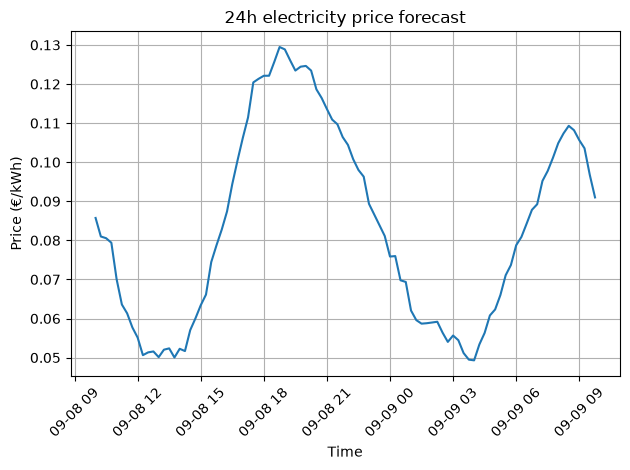

In [6]:
start_time = now

times = [
    start_time + timedelta(minutes=15 * t)
    for t in range(96)
]

plt.plot(times, prices)
plt.xlabel("Time")
plt.ylabel("Price (€/kWh)")
plt.title("24h electricity price forecast")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()


#### CREATE THE OBJECT VEHICLE

In [7]:
@dataclass
class ElectricVehicle:
    id: int
    battery_level: float                #kwh
    battery_capacity: float             #kWh
    time_of_arrival: datetime          
    desired_charge_time: float          #h 
    desired_energy_stated: float        #percentage (as 0.9=90%)
    charge_power: float                 #kW
    discharge_power: float              #kW
    battery_level_theory: float         #kWh to track down how the solutions compare to a more classic solution

In [8]:
# JUST ONE VEHICLE INITIALIZATION, ARBITRARY
id=0
battery_level = 20
battery_capacity = 60
time_of_arrival = now
desired_charge_time = 6.0
desired_energy = 0.9
charge_power = 22
discharge_power = 11
battery_level_theory = battery_level

vehicles = [ElectricVehicle(
    id,
    battery_level,
    battery_capacity,
    time_of_arrival,
    desired_charge_time,
    desired_energy,
    charge_power,
    discharge_power,
    battery_level_theory)]

### OPTIMIZATION MODEL

In [12]:
def build_milp(vehicles, prices, granularity, horizon, current_time):

    model = pyo.ConcreteModel()


    ### Sets

    model.V = pyo.Set(initialize=[v.id for v in vehicles])  #Vehicles index
    model.T = pyo.RangeSet(0, horizon - 1)                  #Time frames, from 0 being now, to horizon being horizon * granularity = 1 day
    model.T_energy = pyo.RangeSet(0, horizon)               #Time frames + 1 for energy evolution



    ###DECISION VARIABLE

    model.charge = pyo.Var(
        model.V,
        model.T,
        within=pyo.NonNegativeReals
    )
    # Current charging power within time frame T for vehicle V

    model.discharge = pyo.Var(
        model.V,
        model.T,
        within=pyo.NonNegativeReals
    )
    # Current discharging power within time frame T for vehicle V



    ### STATE VARIABLES

    # ENERGY AT EVERY STEP

    model.energy = pyo.Var(
        model.V,
        model.T_energy,
        within=pyo.NonNegativeReals
    )
    # energy/battery level at time T, for vehicle V

    # is charging?

    model.is_charging = pyo.Var(
        model.V,
        model.T,
        within=pyo.Binary
    )
    #just a binary value to avoid charging and discharging

    ###OBJECTIVE FUNCTION

    model.objective = pyo.Objective(
        expr=sum(
            (
                prices[t] * (model.charge[v, t]
                - model.discharge[v, t])
            ) * granularity/60
            for v in model.V
            for t in model.T
        ),
        sense=pyo.minimize
    )
    # could be made more complicated with efficiency of charging, cost on the battery wear etc. 
    # For now it's just the direct Cost of electricity without grid prices


    ### CONSTRAINTS

    # CHARGE LIMIT

    def charge_limit_rule(model, v, t):
        vehicle = next(vehicle for vehicle in vehicles if vehicle.id == v)

        return model.charge[v, t] <= vehicle.charge_power

    model.charge_limit = pyo.Constraint(
        model.V,
        model.T,
        rule=charge_limit_rule
    )

    # Charging power < Max charging power by vehicle V


    # DISCHARGE LIMIT

    def discharge_limit_rule(model, v, t):
        vehicle = next(vehicle for vehicle in vehicles if vehicle.id == v)

        return model.discharge[v, t] <= vehicle.discharge_power

    model.discharge_limit = pyo.Constraint(
        model.V,
        model.T,
        rule=discharge_limit_rule
    )

    # Disharging power < Max discharging power by vehicle V



    # INITIAL

    def initial_energy_rule(model, v):
        vehicle = next(vehicle for vehicle in vehicles if vehicle.id == v)

        return model.energy[v, 0] == vehicle.battery_level

    model.initial_energy = pyo.Constraint(
        model.V,
        rule=initial_energy_rule
    )

    #Battery level is given at t=0 (rolling) so energy(v,0)=0



    # ENERGY EVOLUTION

    dt = granularity / 60  # hours

    def energy_evolution_rule(model, v, t):
        return model.energy[v, t + 1] == (
            model.energy[v, t]
            + model.charge[v, t] * dt
            - model.discharge[v, t] * dt
        )

    model.energy_evolution = pyo.Constraint(
        model.V,
        model.T,
        rule=energy_evolution_rule
    )
    #theoritical evolution of energy level in the car as scheduled (it is only updated at object level when the time update)
    #energy(v,t+1) = energy(v,t) + charge(v,t)*dt - discharge(v,t)*dt



    # AVOID CHARGING AND DISCHARGING

    def charging_status_rule(model, v, t):
        vehicle = next(vehicle for vehicle in vehicles if vehicle.id == v)

        return model.charge[v, t] <= vehicle.charge_power * model.is_charging[v, t]

    model.charging_status = pyo.Constraint(
        model.V,
        model.T,
        rule=charging_status_rule
    )

    def discharging_status_rule(model, v, t):
        vehicle = next(vehicle for vehicle in vehicles if vehicle.id == v)

        return model.discharge[v, t] <= vehicle.discharge_power * (1 - model.is_charging[v, t])

    model.discharging_status = pyo.Constraint(
        model.V,
        model.T,
        rule=discharging_status_rule
    )

    #if charge(v,t)>0, discharge(v,t)=0 and reciprocal



    # ENERGY SHOULD ALWAYS BE OVER 20% (EXCEPT WHEN IT STARTED CHARGING BELOW)

    def minimum_energy_rule(model, v, t):
        vehicle = next(vehicle for vehicle in vehicles if vehicle.id == v)

        E0 = vehicle.battery_level
        E_min = 0.2 * vehicle.battery_capacity

        required_energy = min(
            E_min,
            E0 + vehicle.charge_power * t * dt
        )

        return model.energy[v, t] >= required_energy

    model.minimum_energy = pyo.Constraint(
        model.V,
        model.T_energy,
        rule=minimum_energy_rule
    )

    #energy(v,t)>0.2 or energy(v,t)>energy(v,0)+charge_max_from_0_to_t




    # ENERGY SHOULD REACH THE ENERGY WISHED AT THE TIME STATED IF POSSIBLE (OTHERWISE CHARGE AS MUCH AS POSSIBLE)

    def departure_energy_rule(model, v):
        vehicle = next(vehicle for vehicle in vehicles if vehicle.id == v)

        E0 = vehicle.battery_level
        E_target = vehicle.desired_energy_stated * vehicle.battery_capacity

        time_available = max(0,vehicle.desired_charge_time - (current_time-vehicle.time_of_arrival).total_seconds()/3600)

        E_max_possible = (
            E0 + vehicle.charge_power * time_available
        )

        E_required = min(E_target, E_max_possible)

        departure_t = int(time_available / dt)

        return model.energy[v, departure_t] >= E_required


    model.departure_energy = pyo.Constraint(
        model.V,
        rule=departure_energy_rule
    )

    #energy(v,t_defined(v)) = Energy_defined(v) OR energy(v,t_defined(v)) = energy(v,0) + charge_max_from_0_to_t_defined_for_v



    # ENERGY IS BOUNDED

    def capacity_rule(model, v, t):
        vehicle = next(vehicle for vehicle in vehicles if vehicle.id == v)

        return model.energy[v, t] <= vehicle.battery_capacity

    model.capacity = pyo.Constraint(
        model.V,
        model.T_energy,
        rule=capacity_rule
    )

    #energy(v,t)<capacity(v)


    # CHARGING MUST BE ZERO AFTER DEPARTURE
    def unplugged_charge_rule(model, v, t):
        vehicle = next(vehicle for vehicle in vehicles if vehicle.id == v)

        time_available = max(0,vehicle.desired_charge_time - (current_time-vehicle.time_of_arrival).total_seconds()/3600)

        departure_t = int(time_available / dt)

        if t >= departure_t:
            return model.charge[v, t] == 0

        return pyo.Constraint.Skip

    model.unplugged_charge = pyo.Constraint(
        model.V,
        model.T,
        rule=unplugged_charge_rule
    )


    # DISCHARGING MUST BE ZERO AFTER DEPARTURE
    def unplugged_discharge_rule(model, v, t):
        vehicle = next(vehicle for vehicle in vehicles if vehicle.id == v)

        time_available = max(0,vehicle.desired_charge_time - (current_time-vehicle.time_of_arrival).total_seconds()/3600)
        departure_t = int(time_available / dt)

        if t >= departure_t:
            return model.discharge[v, t] == 0

        return pyo.Constraint.Skip

    model.unplugged_discharge = pyo.Constraint(
        model.V,
        model.T,
        rule=unplugged_discharge_rule
    )

    #charge(v,t) = 0 and discharge(v,t) = 0 if t>t_defined(v)

    return model

### NOW READY TO USE

#### FIRST TRY WITH THE PROBLEM FOR ONE VEHICLE, AT ONE TIME STEP

In [13]:
current_time = now

model = build_milp(vehicles, prices, granularity, horizon, current_time)

solver = pyo.SolverFactory("highs")

results = solver.solve(model, tee=True)


#### RESULTS:


print("Minimized cost:", pyo.value(model.objective))

Running HiGHS 1.15.1 (git hash: 04024d7): Copyright (c) 2026 under MIT licence terms
Includes third-party software components, see THIRD_PARTY_NOTICES.md for full details
MIP has 820 rows; 385 cols; 1300 nonzeros; 96 integer variables (96 binary)
Coefficient ranges:
  Matrix  [2e-01, 2e+01]
  Cost    [1e-02, 3e-02]
  Bound   [1e+00, 1e+00]
  RHS     [1e+01, 6e+01]
Presolving model
287 rows, 167 cols, 333 nonzeros 0s
71 rows, 95 cols, 189 nonzeros 0s
70 rows, 94 cols, 187 nonzeros 0s
Presolve reductions: rows 70(-750); columns 94(-291); nonzeros 187(-1113) 

Solving MIP model with:
   70 rows
   94 cols (24 binary, 0 integer, 0 implied int., 70 continuous, 0 domain fixed)
   187 nonzeros
   Thread count 8 (of 16 threads). Using 1 max workers. Parallel search off

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => 


Vehicle 0
t= 0 | energy= 20.00 kWh | charge= 0.00 kW | discharge=11.00 kW
t= 1 | energy= 17.25 kWh | charge= 0.00 kW | discharge=11.00 kW
t= 2 | energy= 14.50 kWh | charge= 0.00 kW | discharge=10.00 kW
t= 3 | energy= 12.00 kWh | charge= 0.00 kW | discharge= 0.00 kW
t= 4 | energy= 12.00 kWh | charge= 0.00 kW | discharge= 0.00 kW
t= 5 | energy= 12.00 kWh | charge= 0.00 kW | discharge= 0.00 kW
t= 6 | energy= 12.00 kWh | charge= 0.00 kW | discharge= 0.00 kW
t= 7 | energy= 12.00 kWh | charge= 0.00 kW | discharge= 0.00 kW
t= 8 | energy= 12.00 kWh | charge= 0.00 kW | discharge= 0.00 kW
t= 9 | energy= 12.00 kWh | charge=22.00 kW | discharge= 0.00 kW
t=10 | energy= 17.50 kWh | charge=22.00 kW | discharge= 0.00 kW
t=11 | energy= 23.00 kWh | charge=22.00 kW | discharge= 0.00 kW
t=12 | energy= 28.50 kWh | charge=22.00 kW | discharge= 0.00 kW
t=13 | energy= 34.00 kWh | charge=22.00 kW | discharge= 0.00 kW
t=14 | energy= 39.50 kWh | charge=16.00 kW | discharge= 0.00 kW
t=15 | energy= 43.50 kWh | ch

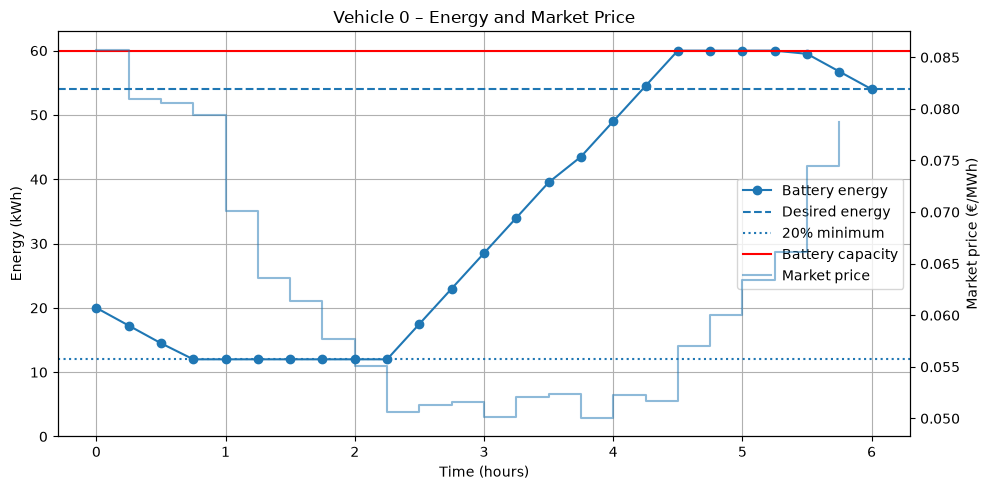

In [17]:
for v in vehicles:
    departure_t = int(v.desired_charge_time / dt)

    print(f"\nVehicle {v.id}")

    for t in range(departure_t + 1):
        charge = pyo.value(model.charge[v.id, t])
        discharge = pyo.value(model.discharge[v.id, t])
        energy = pyo.value(model.energy[v.id, t])

        print(
            f"t={t:2d} | "
            f"energy={energy:6.2f} kWh | "
            f"charge={charge:5.2f} kW | "
            f"discharge={discharge:5.2f} kW"
        )


## VISUALIZE

dt = granularity / 60

for v in vehicles:
    # Departure timestep
    departure_t = int(v.desired_charge_time / dt)

    # -------------------------
    # Energy data
    # -------------------------
    times_energy = [
        t * dt
        for t in range(departure_t + 1)
    ]

    energy = [
        pyo.value(model.energy[v.id, t])
        for t in range(departure_t + 1)
    ]

    # -------------------------
    # Price data
    # -------------------------
    times_price = [
        t * dt
        for t in range(departure_t)
    ]

    vehicle_prices = prices[:departure_t]

    # -------------------------
    # Create figure
    # -------------------------
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Battery energy
    ax1.plot(
        times_energy,
        energy,
        marker="o",
        label="Battery energy"
    )

    # Desired energy
    target_energy = (
        v.desired_energy_stated
        * v.battery_capacity
    )

    ax1.axhline(
        target_energy,
        linestyle="--",
        label="Desired energy"
    )

    # 20% minimum
    minimum_energy = 0.2 * v.battery_capacity

    ax1.axhline(
        minimum_energy,
        linestyle=":",
        label="20% minimum"
    )

    # Battery capacity
    ax1.axhline(
        v.battery_capacity,
        color="red",
        linestyle="-",
        label="Battery capacity"
    )

    # -------------------------
    # Left axis
    # -------------------------
    ax1.set_xlabel("Time (hours)")
    ax1.set_ylabel("Energy (kWh)")

    ax1.set_ylim(
        0,
        v.battery_capacity * 1.05
    )

    ax1.grid(True)

    # -------------------------
    # Right axis: price
    # -------------------------
    ax2 = ax1.twinx()

    ax2.step(
        times_price,
        vehicle_prices,
        where="post",
        alpha=0.5,
        label="Market price"
    )

    ax2.set_ylabel("Market price (€/MWh)")

    # -------------------------
    # Combined legend
    # -------------------------
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc="best"
    )

    # -------------------------
    # Title
    # -------------------------
    plt.title(
        f"Vehicle {v.id} – Energy and Market Price"
    )

    plt.tight_layout()
    if v.id == 2:
        plt.show()

### TEMPORAL EVOLUTION

First we need to be able to update the prices we use in the simulation. Note. this would be useless when we have real data

In [31]:
def update_prices(
    prices,
    current_time,
    granularity,
    horizon,
    rng
):


    dt = granularity / 60

    # Remove the price that has just passed
    prices.pop(0)
    last_price=prices[-1]

    # Generate the new price at the end of the horizon
    new_time = current_time + timedelta(minutes = granularity) + timedelta(minutes = granularity * horizon)

    new_price = price_at_time(
        new_time.hour,
        rng,
        last_price
    )

    prices.append(new_price)

    return prices,rng

Let's generate more automatically vehicles, with vehicles types

#### Types of vehicles (parameters):

In [26]:
car_profiles = [
        {"capacity": 35.0, "max_charge": 7.4,  "max_discharge": 0.0},   # small EV, AC-only
        {"capacity": 60.0, "max_charge": 11.0, "max_discharge": 7.0},   # mid-size, V2G-capable
        {"capacity": 85.0, "max_charge": 22.0, "max_discharge": 10.0},  # large EV
        {"capacity": 42.0, "max_charge": 8,  "max_discharge": 0.0},   # small EV, AC-only
        {"capacity": 65.0, "max_charge": 10.0, "max_discharge": 6.0},   # mid-size, V2G-capable
        {"capacity": 90.0, "max_charge": 30.0, "max_discharge": 15.0},  # large EV
    ]

Sample of vehicle: when a new vehicle arrive we generate all the variables
We have to generate also a desired parking time, which is here a normal distribution with higher means at day time (workplace stop) or night time (overnight parking). This is arbitrary, for making the simulation works.

In [27]:
def generate_parking_time(current_time, rng):
    if 6 <= current_time.hour < 10:
        # Morning → workday
        parking_time = rng.normal(8, 1.5)
    elif 10 <= current_time.hour  < 16:
        # Midday → shorter stay
        parking_time = rng.normal(4, 1.5)
    elif 16 <= current_time.hour  < 21:
        # Evening → overnight
        parking_time = rng.normal(14, 2)
    else:
        # Night
        parking_time = rng.normal(7, 2)
    return max(round(parking_time/(granularity/60))*0.25, 0.25)

def sample_vehicle(last_id,current_time,rng):
    id = last_id + 1
    profile = np.random.choice(car_profiles)
    battery_capacity = profile["capacity"]
    battery_level = round(np.random.uniform(0.1,0.6),2)*battery_capacity
    time_frame_desired = generate_parking_time(current_time,rng)
    charge_power = profile["max_charge"]
    discharge_power = profile["max_discharge"]
    battery_level_desired = 0.8 if np.random.random()>0.5 else 1
    battery_level_theory = battery_level

    return ElectricVehicle(id, battery_level, battery_capacity, current_time, time_frame_desired, battery_level_desired, charge_power, discharge_power, battery_level_theory)


Every new time interval, we should simulate the number of cars arriving to charging station. For this, we have a poisson process (from queueing theory / mobility courses), with higher rates at peak times

In [28]:
def number_of_arrivals(hour, rng):
    if 7 <= hour < 10:       # morning peak
        rate = 15
    elif 10 <= hour < 16:    # midday
        rate = 10
    elif 16 <= hour < 20:    # afternoon peak
        rate = 15
    else:                    # night
        rate = 2
    return rng.poisson(rate * 0.25)


In [29]:
current_time = now
drop_rate = 0.02            #probability a vehicle does not stay until the time stated
max_vehicles = 100          #to cap the system, as a poisson process can explodes if not properly defined
last_id = len(vehicles)

real_cost=[]                #cost in our optimizer
theory_cost=[]              #cost if all the cars were charging directly, "dumbly"

SCRIPT FOR TIME EVOLUTION

In [32]:
for i in range(24):
    real_cost.append(0)
    theory_cost.append(0)
    current_time = current_time + timedelta(minutes = 15)
    #time evolution

    for v in vehicles:
        if v.time_of_arrival + timedelta(hours = v.desired_charge_time) < current_time:
            vehicles.remove(v)
        #if the car is still plugged but passed the time, it's considered as unplugged
        if np.random.random() > (1-drop_rate):
            vehicles.remove(v)
        #emergency unplug drop rates
        else:
            v.battery_level += (
                pyo.value(model.charge[v.id, 0]) - pyo.value(model.discharge[v.id, 0])) * dt
            #battery level update at object level
            real_cost[i]+=(pyo.value(model.charge[v.id, 0]) - pyo.value(model.discharge[v.id, 0])) * dt * prices[0]
            #cost update from optimizer
            if v.battery_level_theory + v.charge_power * dt < v.battery_capacity:
                v.battery_level_theory += v.charge_power * dt
                theory_cost[i]+=v.charge_power * dt * prices[0]
            else:
                theory_cost[i] += (v.battery_capacity - v.battery_level_theory)*prices[0]
                v.battery_level_theory = v.battery_capacity
            #"dumb" cost update

    #update of the prices
    prices,rng = update_prices(prices, current_time, granularity, horizon, rng)
    #generate new vehicles getting plugged
    number_of_vehicle_to_sample = number_of_arrivals(current_time.hour,rng)
    #sampling the new vehicles
    for i in range(number_of_vehicle_to_sample):
        if len(vehicles) < max_vehicles:
            new_vehicle = sample_vehicle(last_id,current_time,rng)
            last_id = last_id + 1
        vehicles.append(new_vehicle)

    #solve model at each time step
    model = build_milp(vehicles, prices, granularity, horizon, current_time)
    solver = pyo.SolverFactory("highs")
    results = solver.solve(model, tee=True)

Running HiGHS 1.15.1 (git hash: 04024d7): Copyright (c) 2026 under MIT licence terms
Includes third-party software components, see THIRD_PARTY_NOTICES.md for full details
MIP has 6696 rows; 3080 cols; 10440 nonzeros; 768 integer variables (768 binary)
Coefficient ranges:
  Matrix  [2e-01, 3e+01]
  Cost    [1e-02, 3e-02]
  Bound   [1e+00, 1e+00]
  RHS     [6e+00, 9e+01]
Presolving model
2113 rows, 1110 cols, 2212 nonzeros 0s
340 rows, 463 cols, 909 nonzeros 0s
312 rows, 360 cols, 714 nonzeros 0s
236 rows, 331 cols, 657 nonzeros 0s
233 rows, 328 cols, 651 nonzeros 0s
Presolve reductions: rows 233(-6463); columns 328(-2752); nonzeros 651(-9789) 

Solving MIP model with:
   233 rows
   328 cols (96 binary, 0 integer, 0 implied int., 232 continuous, 0 domain fixed)
   651 nonzeros
   Thread count 8 (of 16 threads). Using 1 max workers. Parallel search off

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-M

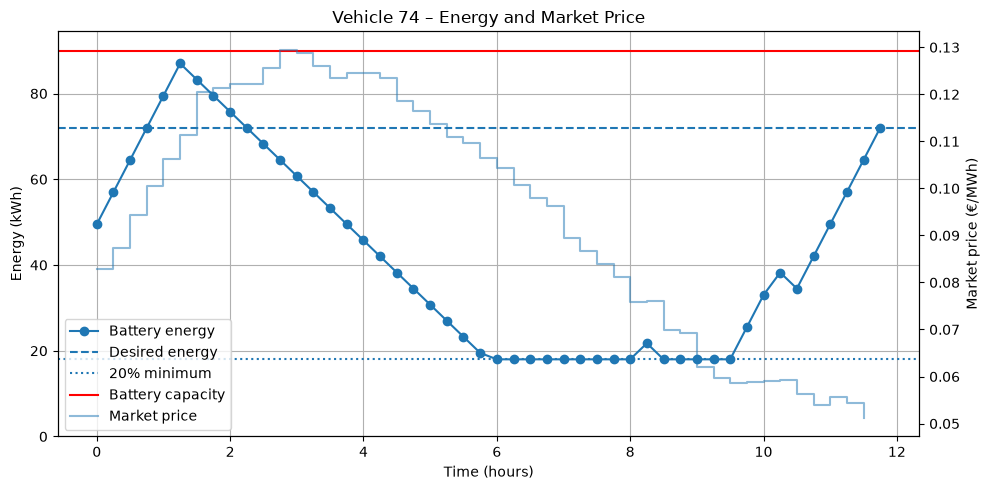

In [39]:
### VISUALIZE

dt = granularity / 60

#Arbitrary
vehicle_to_check = 1

if len(vehicles)>vehicle_to_check:
    v=vehicles[-1]

    # Departure timestep
    time_available = max(0,v.desired_charge_time - (current_time-v.time_of_arrival).total_seconds()/3600)
    departure_t = int(time_available / dt)

    # -------------------------
    # Energy data
    # -------------------------
    times_energy = [
        t * dt
        for t in range(departure_t + 1)
    ]

    energy = [
        pyo.value(model.energy[v.id, t])
        for t in range(departure_t + 1)
    ]

    # -------------------------
    # Price data
    # -------------------------
    times_price = [
        t * dt
        for t in range(departure_t)
    ]

    vehicle_prices = prices[:departure_t]

    # -------------------------
    # Create figure
    # -------------------------
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Battery energy
    ax1.plot(
        times_energy,
        energy,
        marker="o",
        label="Battery energy"
    )

    # Desired energy
    target_energy = (
        v.desired_energy_stated
        * v.battery_capacity
    )

    ax1.axhline(
        target_energy,
        linestyle="--",
        label="Desired energy"
    )

    # 20% minimum
    minimum_energy = 0.2 * v.battery_capacity

    ax1.axhline(
        minimum_energy,
        linestyle=":",
        label="20% minimum"
    )

    # Battery capacity
    ax1.axhline(
        v.battery_capacity,
        color="red",
        linestyle="-",
        label="Battery capacity"
    )

    # -------------------------
    # Left axis
    # -------------------------
    ax1.set_xlabel("Time (hours)")
    ax1.set_ylabel("Energy (kWh)")

    ax1.set_ylim(
        0,
        v.battery_capacity * 1.05
    )

    ax1.grid(True)

    # -------------------------
    # Right axis: price
    # -------------------------
    ax2 = ax1.twinx()

    ax2.step(
        times_price,
        vehicle_prices,
        where="post",
        alpha=0.5,
        label="Market price"
    )

    ax2.set_ylabel("Market price (€/MWh)")

    # -------------------------
    # Combined legend
    # -------------------------
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc="best"
    )

    # -------------------------
    # Title
    # -------------------------
    plt.title(
        f"Vehicle {v.id} – Energy and Market Price"
    )

    plt.tight_layout()
    plt.show()

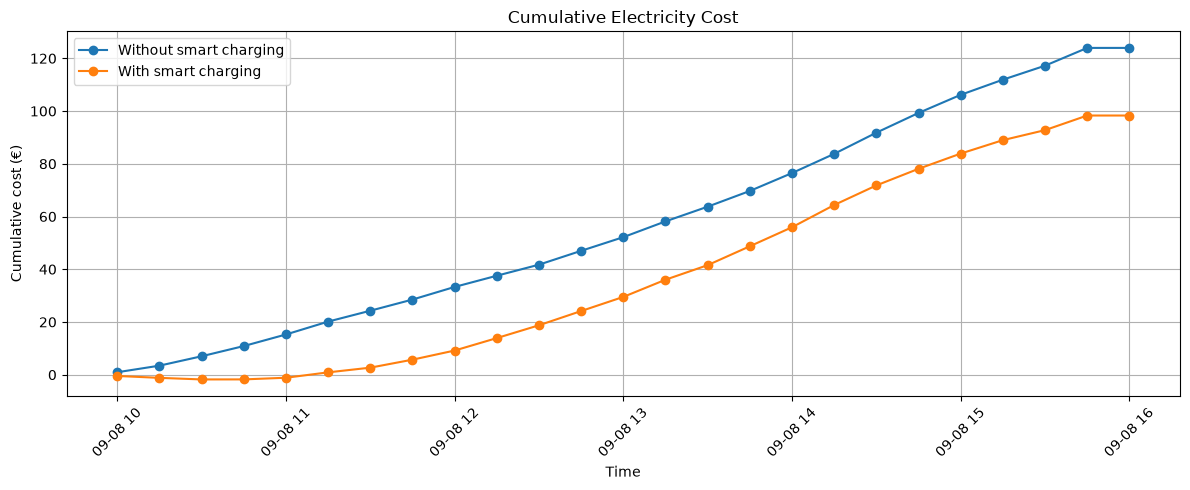

In [42]:
cumulative_without_smart = np.cumsum(theory_cost)
cumulative_with_smart = np.cumsum(real_cost)

times = [
    start_time + timedelta(minutes=15 * t)
    for t in range(len(theory_cost))
]

plt.figure(figsize=(12, 5))

plt.plot(
    times,
    cumulative_without_smart,
    marker="o",
    label="Without smart charging"
)

plt.plot(
    times,
    cumulative_with_smart,
    marker="o",
    label="With smart charging"
)

plt.xlabel("Time")
plt.ylabel("Cumulative cost (€)")
plt.title("Cumulative Electricity Cost")
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()